# Práctica 5 - Redes Neuronales Convolucionales

## Ejercicio 1

El archivo **ecg.csv** contiene 5,000 latidos cardíacos provenientes del dataset "ECG5000", una colección de datos de electrocardiograma (ECG) de "BIDMC Congestive Heart Failure Database”. Cada fila representa un ECG completo de un paciente, compuesto por 140 puntos de datos (lecturas). Cada fila contiene una etiqueta que indica si el ECG es normal (valor 1) o anormal (valor 0). La versión original del archivo se encuentra en: https://www.kaggle.com/datasets/devavratatripathy/ecg-dataset

<div style="text-align: center;">
    <img src='../imagenes/p6-ej1.png' width="60%">
</div>

Desarrolle un modelo de autoencoder utilizando redes neuronales densas con TensorFlow/Keras que posibilite diferenciar electrocardiogramas normales de anormales.


In [1]:
FUENTES_DIR = '../Fuentes'         # carpeta donde se encuentran archivos .py auxiliares
DATOS_DIR   = '../Data_Sets/p6/' # carpeta donde se encuentran los datasets
LOCAL_DIR = DATOS_DIR
import sys
sys.path.append(FUENTES_DIR)

In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler

2025-10-31 09:04:14.511478: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-31 09:04:14.785973: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-31 09:04:15.938570: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Carga de Datos e Inspección

In [3]:
nombre_archivo = DATOS_DIR + 'ecg.csv'

# carga archivo de datos. No tiene fila con titulos!
df= pd.read_csv(nombre_archivo, header=None)

raw_data = df.values
df.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


## Preparación de Datos y Normalización

In [4]:
# separa en etiquetas y datos
FEAT_CNT = 140

labels = raw_data[:, -1]    # Etiquetas (última columna)
data = raw_data[:, 0:-1]  # Datos (secuencia de 140 lecturas)


labels = labels.astype(int) # ajustas etiquetas porque tiene valores en punto flotante (0.0/1.0)

# separa en datos de entrenamiento y testeo
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=1
)

# Normalización de datos entre 0 y 1. Los datos son lecturas de una señal acotada en intensidad
scaler = MinMaxScaler()

train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

normal_train_data = train_data[train_labels == 1]
normal_test_data = test_data[test_labels == 1]

anomal_train_data = train_data[train_labels == 0]
anomal_test_data = test_data[test_labels == 0]

## Visualización de Ejemplo de ECG Normal y Anormal

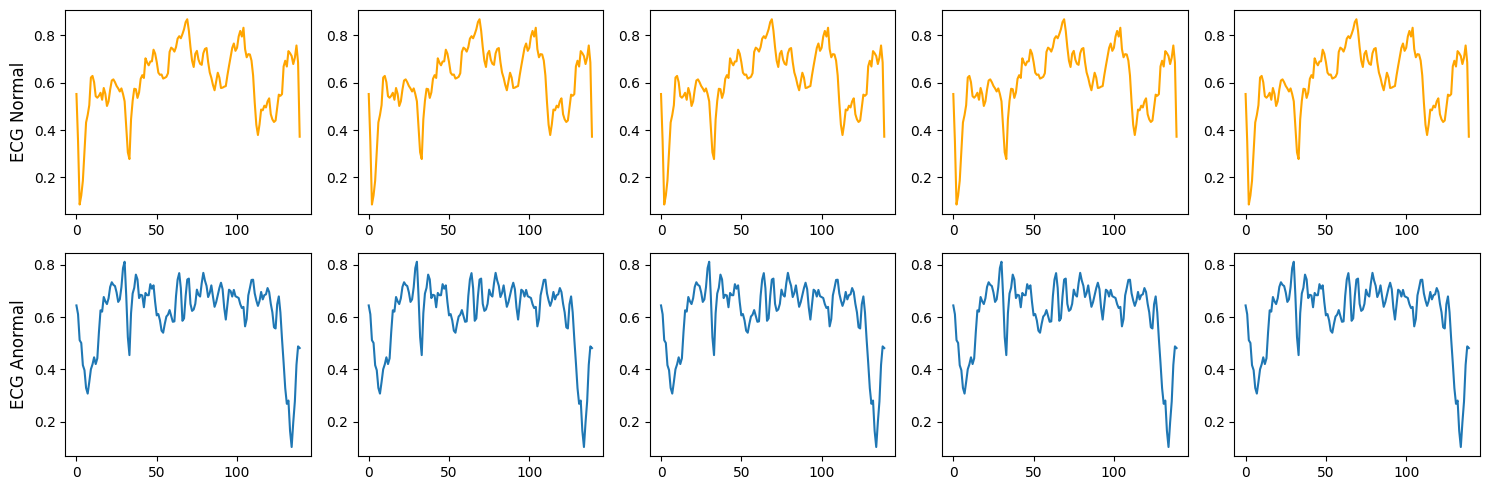

In [5]:
MOSTRAR = 5

fig, axs = plt.subplots(2, MOSTRAR, figsize=(15, 5))  # Ajusta el tamaño de la figura según sea necesario

for i in range(2):
    for j in range(MOSTRAR):
        if i == 0:
            axs[i, j].plot(np.arange(FEAT_CNT), normal_train_data[i], color='orange')  # Cambiar el color de la segunda fila a naranja
        else:
            axs[i, j].plot(np.arange(FEAT_CNT), anomal_train_data[i])  # Gráficos predeterminados para la primera fila

        #axs[i, j].spines['right'].set_visible(False)

# Agregar títulos
axs[0, 0].set_ylabel('ECG Normal' , fontsize=12)
axs[1, 0].set_ylabel('ECG Anormal', fontsize=12)

plt.tight_layout()  # Ajustar automáticamente el espaciado entre subgráficos
plt.show()


## Construcción del Modelo de Autoencoder

In [6]:
from tensorflow.keras import layers, regularizers

# Codificador mejorado
encoder = tf.keras.Sequential([
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu")],  # Espacio latente más grande que 8
    name='Encoder'
)

# Decodificador mejorado
decoder = tf.keras.Sequential([
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu"),
    layers.Dense(140, activation="sigmoid")],  # Mantenemos sigmoid para salida normalizada
    name='Decoder'
)

# Modelo completo del autoencoder
inputs = tf.keras.Input(shape=(140,))
encoded = encoder(inputs)
decoded = decoder(encoded)

autoencoder = tf.keras.Model(
    inputs=inputs,
    outputs=decoded,
    name='ECG_Autoencoder'
)

# Compilación con optimizador ajustado
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='mse',
                  metrics=['mae'])


print(encoder.summary())
print(decoder.summary())
print(autoencoder.summary())


E0000 00:00:1761912257.332753   33582 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1761912257.339865   33582 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,680 (115.94 KB)

 Trainable params: 29,296 (114.44 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Sequential)            │ (None, 16)             │        29,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Sequential)            │ (None, 140)            │        29,420 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,100 (230.86 KB)

 Trainable params: 58,524 (228.61 KB)

 Non-trainable params: 576 (2.25 KB)

None


## Entrenamiento del Modelo

In [7]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',  # Monitorea la pérdida de validación
    patience=10,         # Número de épocas sin mejora antes de detener
    restore_best_weights=True,  # Restaura los mejores pesos encontrados
)

history = autoencoder.fit(
    normal_train_data,
    normal_train_data,
    epochs=300,
    batch_size=64,
    validation_data=(test_data, test_data),
    shuffle=True,
    callbacks=[early_stopping]
)

Epoch 1/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3212 - mae: 0.1701 - val_loss: 0.3003 - val_mae: 0.1508
Epoch 2/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2994 - mae: 0.1488 - val_loss: 0.2865 - val_mae: 0.1454
Epoch 3/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2805 - mae: 0.1320 - val_loss: 0.2722 - val_mae: 0.1368
Epoch 4/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2637 - mae: 0.1180 - val_loss: 0.2577 - val_mae: 0.1254
Epoch 5/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2487 - mae: 0.1067 - val_loss: 0.2438 - val_mae: 0.1136
Epoch 6/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2349 - mae: 0.0971 - val_loss: 0.2311 - val_mae: 0.1042
Epoch 7/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2223 - mae: 0.0888 - val_loss: 0.2196 - val_mae: 0.0978
Epoch 8/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2107 - mae: 0.0824 - val_loss: 0.2086 - val_mae: 0.0915
Epoch 9/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.199

## Visualización de las métricas de entrenamiento

In [8]:
import plotly.graph_objects as go

fig = go.Figure()

# Recorre el historial para agregar todas las métricas automáticamente
for metric_name, metric_values in history.history.items():
    modo = 'lines' if 'loss' in metric_name else 'markers+lines'
    fig.add_trace(
        go.Scatter(
            y=metric_values,
            name=metric_name,
            mode=modo
        )
    )

fig.update_layout(
    title='Métricas de Entrenamiento',
    xaxis_title='Épocas',
    yaxis_title='Valor',
    template='plotly_white'
)

fig.show()

## Reconstrucción de ECG Normal y Anormal

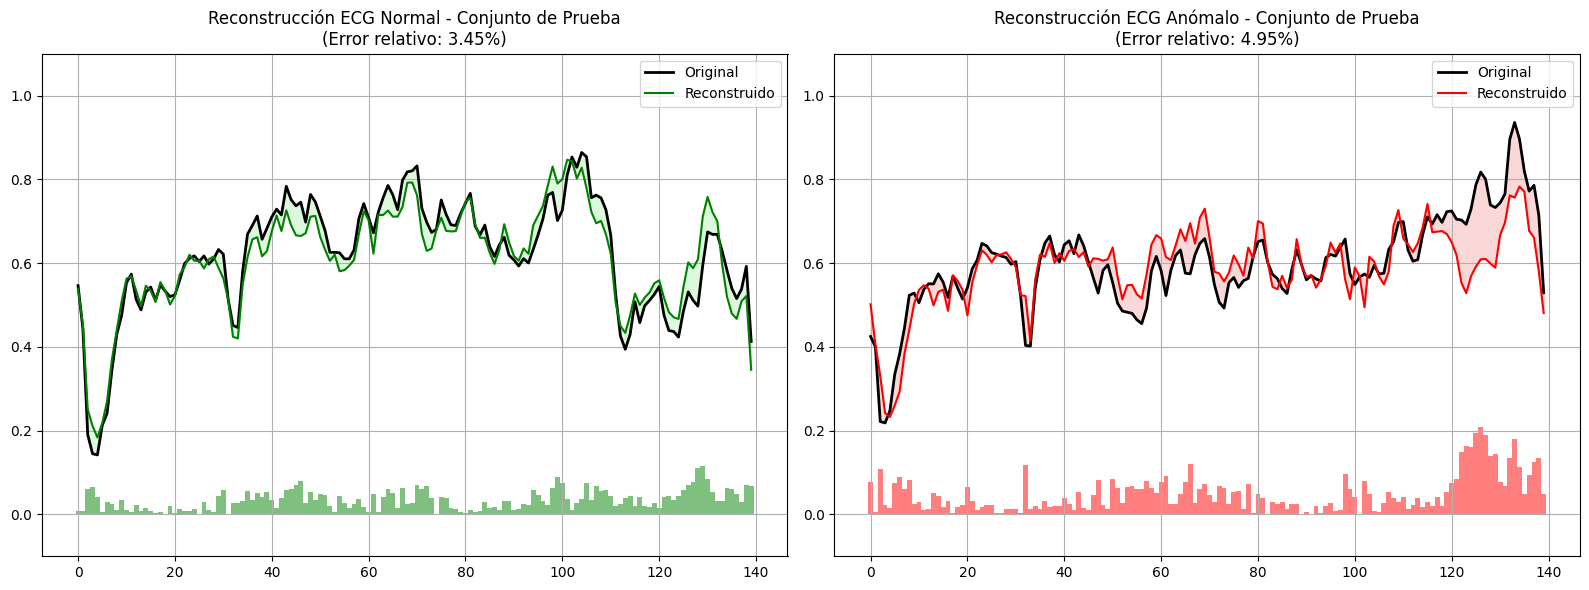

In [9]:
plt.figure(figsize=(16, 6))

# Calcula las reconstrucciones con el dataset de prueba
# ECG Normal
encoded_normal = encoder(normal_test_data).numpy()
decoded_normal = decoder(encoded_normal).numpy()

# ECG Anómalo
encoded_anomal = encoder(anomal_test_data).numpy()
decoded_anomal = decoder(encoded_anomal).numpy()

########## ECG Normal ##########
plt.subplot(1, 2, 1)
plt.title("Reconstrucción ECG Normal - Conjunto de Prueba\n(Error relativo: {:.2f}%)".format(
    100*np.mean(np.abs(normal_test_data[0] - decoded_normal[0]))))
plt.plot(normal_test_data[0], 'black', linewidth=2, label="Original")
plt.plot(decoded_normal[0], 'green', linewidth=1.5, label="Reconstruido")
plt.fill_between(np.arange(140), normal_test_data[0], decoded_normal[0],
                color='lightgreen', alpha=0.3)

# Error relativo por punto
point_error_normal = np.abs(normal_test_data[0] - decoded_normal[0])
plt.bar(np.arange(140), point_error_normal, color='green', alpha=0.5, width=1)

plt.legend()
plt.grid(True)
plt.ylim(-0.1, 1.1)

########## ECG Anómalo ###########
plt.subplot(1, 2, 2)
plt.title("Reconstrucción ECG Anómalo - Conjunto de Prueba\n(Error relativo: {:.2f}%)".format(
    100*np.mean(np.abs(anomal_test_data[0] - decoded_anomal[0]))))
plt.plot(anomal_test_data[0], 'black', linewidth=2, label="Original")
plt.plot(decoded_anomal[0], 'red', linewidth=1.5, label="Reconstruido")
plt.fill_between(np.arange(140), anomal_test_data[0], decoded_anomal[0],
                color='lightcoral', alpha=0.3)

# Grafica elrror relativo por punto
point_error_anomal = np.abs(anomal_test_data[0] - decoded_anomal[0])
plt.bar(np.arange(140), point_error_anomal, color='red', alpha=0.5, width=1)

plt.legend()
plt.grid(True)
plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

## Análisis de Errores de Reconstrucción

Los siguientes gráficos muestran la capacidad del autoencoder de distinguir entre señales normales y anómalas, se calcula el error absoluto medio (MAE) entre cada señal de prueba y su correspondiente reconstrucción.

### Señales normales

En el primer gráfico (arriba a la izquierda), se muestra un histograma de los errores de reconstrucción de las señales normales del conjunto de prueba. La mayoría de los errores se agrupan en torno a un valor bajo, lo que indica que el modelo logra reconstruir correctamente este tipo de señales. Se grafican la media (línea negra punteada) y una desviación estándar por encima y por debajo de la media (líneas azules punteadas).

### Señales anómalas

En el segundo gráfico (arriba a la derecha), se representa la distribución de errores para señales anómalas. Los errores son considerablemente más altos y su dispersión también es mayor, lo que sugiere que el modelo tiene dificultades para reconstruir señales que no pertenecen al patrón aprendido durante el entrenamiento.

### Comparación conjunta

El gráfico inferior compara ambas distribuciones mediante curvas de densidad. Se observa una clara separación entre los errores típicos de reconstrucción para señales normales (en verde) y anómalas (en rojo). Esta diferencia puede ser aprovechada para establecer un umbral para clasificar automáticamente nuevos señales como normales o anormales según su error de reconstrucción.

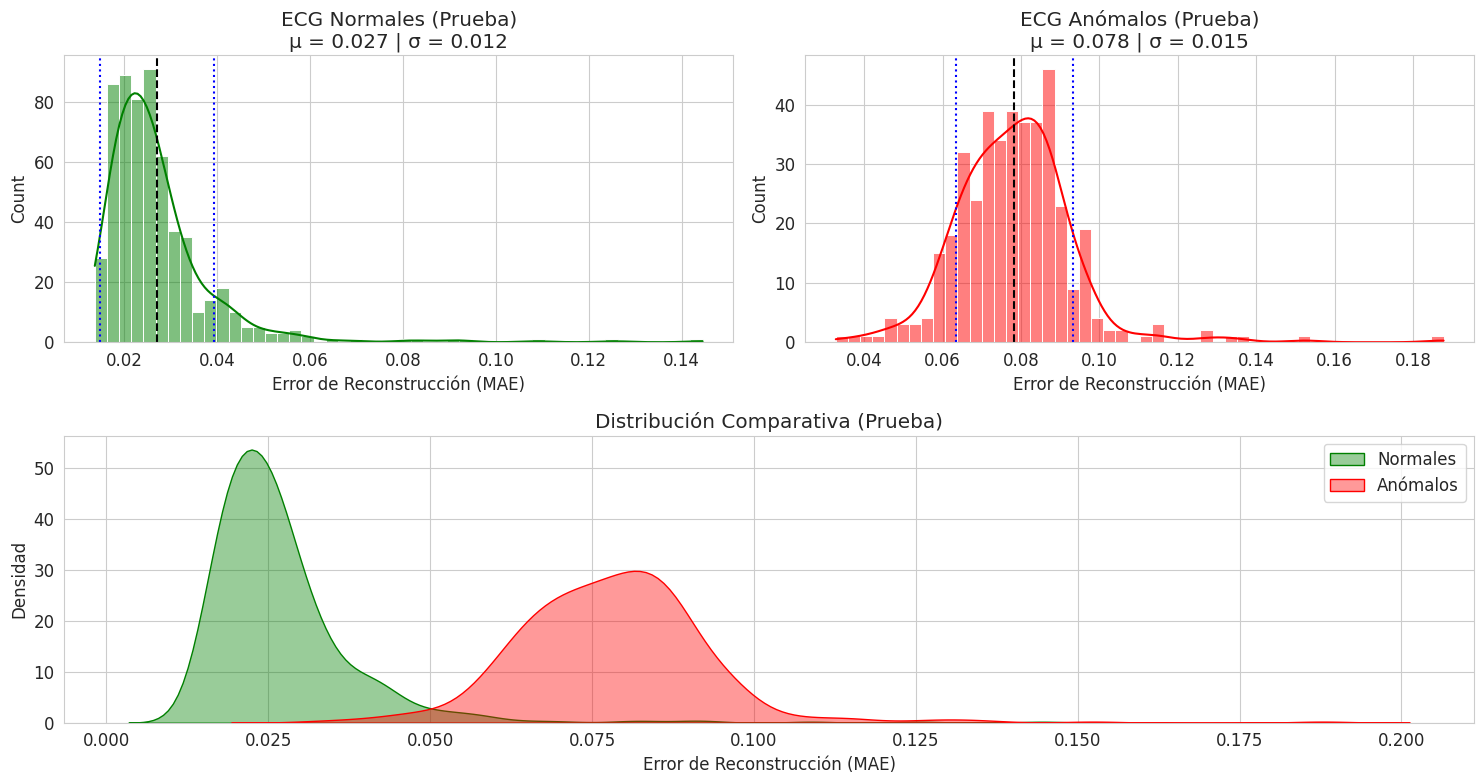

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# Calcula predicciones con datos de prueba
pred_normal = autoencoder.predict(normal_test_data, verbose=0)
pred_anormal = autoencoder.predict(anomal_test_data, verbose=0)

# Calcula errores de reconstrucción
prb_normal = tf.keras.losses.mae(pred_normal, normal_test_data)
prb_anomalo = tf.keras.losses.mae(pred_anormal, anomal_test_data)

# ########## Gráfico 1: Normales ##########
plt.subplot(2, 2, 1)

# calcula media y desvio sobre los ECG normales
media, desvio = np.mean(prb_normal), np.std(prb_normal)

sns.histplot(prb_normal, color='green', kde=True, bins=50)

plt.axvline(media, color='black', linestyle='--', linewidth=1.5)
plt.axvline(media + desvio, color='blue', linestyle=':', linewidth=1.5)
plt.axvline(media - desvio, color='blue', linestyle=':', linewidth=1.5)
plt.title(f'ECG Normales (Prueba)\nμ = {media:.3f} | σ = {desvio:.3f}')
plt.xlabel('Error de Reconstrucción (MAE)')

# ########## Gráfico 2: Anómalos ##########
plt.subplot(2, 2, 2)

# calcula media y desvio sobre los ECG normales
media, desvio = np.mean(prb_anomalo), np.std(prb_anomalo)

sns.histplot(prb_anomalo, color='red', kde=True, bins=50)

plt.axvline(media, color='black', linestyle='--', linewidth=1.5)
plt.axvline(media + desvio, color='blue', linestyle=':', linewidth=1.5)
plt.axvline(media - desvio, color='blue', linestyle=':', linewidth=1.5)
plt.title(f'ECG Anómalos (Prueba)\nμ = {media:.3f} | σ = {desvio:.3f}')
plt.xlabel('Error de Reconstrucción (MAE)')

# ########## Gráfico 3: Combinación ##########
plt.subplot(2, 1, 2)
sns.kdeplot(prb_normal, color='green', label='Normales', fill=True, alpha=0.4)
sns.kdeplot(prb_anomalo, color='red', label='Anómalos', fill=True, alpha=0.4)
plt.title('Distribución Comparativa (Prueba)')
plt.xlabel('Error de Reconstrucción (MAE)')
plt.ylabel('Densidad')
plt.legend()

plt.tight_layout()
plt.show()